# Taller 02: Poda Alfa Beta 
- Inteligencia Artificial ELP 8012 - Universidad del Norte - Profesor: Eduardo Zurek, PH.D. 
- **Grupo:** Natalia Carpintero, Paula Núñez e Isabella Arrieta.
- **Objetivo:** Diseñe e implemente un algoritmo de Poda Alfa Beta que se pueda aplicar de forma genérica a un árbol presentado usando listas de Python.

## Guía rápida para entender el árbol y la poda alfa-beta

https://youtu.be/I0y-TGehf-4?si=z9DLF0E50HZ5fRQX 

1. **¿Cómo se representa cada nivel?**
   - El árbol se representa con **listas anidadas**.
   - Cada lista corresponde a un nodo interno.
   - Cada número corresponde a una **hoja**.
   - Ejemplo: `[[[3, 5], [6, 9]], [[1, 2], [8, 4]], [[7, 10], [2, 6]]]`.
   - El primer nivel contiene 3 hijos, cada hijo contiene 2 subárboles, y cada subárbol contiene hojas.

2. **¿Quién es MAX y quién MIN en cada nivel?**
   - La raíz se define al crear el solver con `preferencia = "max"` o `preferencia = "min"`.
   - Si la raíz es `MAX`, los niveles alternan así: `MAX -> MIN -> MAX -> MIN`.
   - Si la raíz es `MIN`, los niveles alternan así: `MIN -> MAX -> MIN -> MAX`.
   - El nivel se decide por la profundidad del nodo.

3. **¿Cómo se obtiene la secuencia de jugadas?**
   - En cada nivel se guarda el índice del hijo elegido.
   - Si la mejor jugada está en el hijo 2 del nivel raíz y luego en el hijo 1 del siguiente nivel, la secuencia parcial sería `[2, 1]`.
   - La secuencia completa se arma al unir los índices elegidos desde la raíz hasta la hoja final.
   - Esa secuencia está en `secuencia_optima`.

4. **¿Cómo se identifica exactamente una rama podada?**
   - Una rama queda podada cuando ya no puede mejorar el resultado actual.
   - En `MAX`, se poda cuando `alfa >= beta`.
   - En `MIN`, se poda cuando `alfa >= beta`.
   - La rama podada se guarda con su `path`, que indica exactamente qué posición del árbol fue descartada.
   - En la traza también aparece el motivo de la poda y los valores de `alfa` y `beta` en ese momento.

5. **¿Cómo se representa un árbol de 1, 2, 3, 4 y 5 niveles?**
   - **1 nivel:** `[3, 5, 2]`
   - **2 niveles:** `[[3, 5], [6, 9]]`
   - **3 niveles:** `[[[3, 5], [6, 9]], [[1, 2], [8, 4]]]`
   - **4 niveles:** `[[[[3], [5]], [[6], [9]]], [[[1], [2]], [[8], [4]]]]`
   - **5 niveles:** `[[[[[3]], [[5]]], [[[6]], [[9]]]], [[[[1]], [[2]]], [[[8]], [[4]]]]]`

La idea general es leer el árbol de arriba hacia abajo, alternando MAX y MIN, y seguir solo la ruta que produce el mejor valor sin explorar ramas que ya no aportan.

### ¿Cómo se determinan alfa y beta?

- **Alfa ($\alpha$)** es el mejor valor que ha encontrado **MAX** hasta el momento.
- **Beta ($\beta$)** es el mejor valor que ha encontrado **MIN** hasta el momento.
- No cambian de significado según el nivel; lo que cambia es **quién los actualiza**.
- En un nodo **MAX** se actualiza `alpha = max(alpha, valor_hijo)`.
- En un nodo **MIN** se actualiza `beta = min(beta, valor_hijo)`.
- La poda ocurre cuando `alpha >= beta`, porque ya no tiene sentido seguir explorando esa rama.

### Regla por nivel

- Si la raíz es `MAX`, los niveles quedan: `MAX -> MIN -> MAX -> MIN`.
- Si la raíz es `MIN`, los niveles quedan: `MIN -> MAX -> MIN -> MAX`.
- El criterio del nivel depende de la **profundidad** del nodo, no del valor de las hojas.

### Idea práctica

- **MAX** intenta subir el valor de `alpha`.
- **MIN** intenta bajar el valor de `beta`.
- Si en algún punto `alpha` ya es mayor o igual que `beta`, la rama se poda porque el resultado ya no puede mejorar.

### Descripción de la implementación

Esta notebook implementa poda alfa-beta usando una clase `AlphaBetaSolver`.

- La preferencia inicial de la raíz se define al crear el objeto con `preferencia = "max"` o `preferencia = "min"`.
- El árbol se representa con listas anidadas de Python.
- El método `minimax(...)` calcula el valor óptimo sin poda.
- El método `alpha_beta_pruning(...)` calcula el valor óptimo con poda alfa-beta y además guarda una traza paso a paso.
- El método `render_tree(...)` imprime el árbol en texto, mostrando comparaciones, actualizaciones de alfa y beta, y ramas podadas.

La estructura general sigue este flujo:

1. Se normaliza la preferencia de la raíz.
2. Configuramos el árbol de entrada (automático - manual).
3. Se recorren los niveles alternando MAX y MIN.
3. Se actualizan `alfa` y `beta` en cada nodo.
4. Cuando se cumple el criterio de poda, se registran las ramas descartadas.
5. Al final se imprime una vista textual del árbol para revisar el proceso y una visualización gráfica.


## Librerías y funciones auxiliares para generar y validar árboles

In [46]:
# ============================================================
#  Librerías y funciones auxiliares para generar y validar árboles
# ============================================================
import random
from math import inf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Límites permitidos para la lista de entrada del árbol de juego
NIVELES_MAX = 5
HOJAS_MAX = 50


def _partir_hojas(total, partes):
    """Reparte 'total' hojas entre 'partes' ramas de forma aleatoria,
    garantizando que cada rama reciba al menos 1 hoja."""
    if partes == 1:
        return [total]
    cortes = sorted(random.sample(range(1, total), partes - 1))
    limites = [0] + cortes + [total]
    return [limites[i + 1] - limites[i] for i in range(partes)]


def _construir_subarbol(profundidad_restante, num_hojas, rango_valores, max_ramificacion):
    """Construye recursivamente un subárbol uniforme (todas las hojas a la
    misma profundidad) con exactamente 'num_hojas' hojas."""
    if profundidad_restante == 1:
        # Los hijos de este nodo son directamente las hojas.
        return [random.randint(*rango_valores) for _ in range(num_hojas)]

    if num_hojas == 1:
        ramas = 1
    else:
        ramas = random.randint(2, min(num_hojas, max_ramificacion))

    reparto = _partir_hojas(num_hojas, ramas)
    return [
        _construir_subarbol(profundidad_restante - 1, hojas_rama, rango_valores, max_ramificacion)
        for hojas_rama in reparto
    ]


def generar_arbol_aleatorio(niveles, num_hojas, rango_valores=(-10, 10), max_ramificacion=4, semilla=None):
    """Genera aleatoriamente la lista anidada que describe un árbol de juego.

    Parámetros
    ----------
    niveles : int
        Número total de niveles del árbol, contando la raíz (nivel 1) y el
        nivel de las hojas (último nivel). Debe estar entre 2 y 5.
    num_hojas : int
        Número total de nodos hoja que tendrá el árbol. Debe estar entre 2 y 50.
    rango_valores : tuple
        Rango (mínimo, máximo) para los valores enteros de las hojas.
    max_ramificacion : int
        Número máximo de hijos que puede tener cada nodo interno.
    semilla : int or None
        Semilla para random, útil para reproducir el mismo árbol.

    Devuelve
    -------
    list
        Lista anidada que representa el árbol (compatible con AlphaBetaSolver).
    """
    if semilla is not None:
        random.seed(semilla)

    if not (2 <= niveles <= NIVELES_MAX):
        raise ValueError(f"'niveles' debe estar entre 2 y {NIVELES_MAX}.")
    if not (2 <= num_hojas <= HOJAS_MAX):
        raise ValueError(f"'num_hojas' debe estar entre 2 y {HOJAS_MAX}.")

    profundidad = niveles - 1  # número de aristas entre la raíz y las hojas
    return _construir_subarbol(profundidad, num_hojas, rango_valores, max_ramificacion)


def analizar_arbol(tree):
    """Calcula cuántos niveles y cuántas hojas tiene una lista de árbol dada."""
    def helper(node, nivel_actual):
        if not isinstance(node, list):
            return 1, nivel_actual  # (hojas, nivel de esta hoja)
        total_hojas = 0
        nivel_max = nivel_actual
        for child in node:
            hojas_hijo, nivel_hijo = helper(child, nivel_actual + 1)
            total_hojas += hojas_hijo
            nivel_max = max(nivel_max, nivel_hijo)
        return total_hojas, nivel_max

    total_hojas, niveles = helper(tree, 1)
    return total_hojas, niveles


def validar_arbol(tree):
    """Verifica que el árbol cumpla los límites del enunciado (<=5 niveles,
    <=50 hojas) e imprime un resumen."""
    total_hojas, niveles = analizar_arbol(tree)
    print(f"Niveles del árbol: {niveles} (máximo permitido: {NIVELES_MAX})")
    print(f"Nodos hoja: {total_hojas} (máximo permitido: {HOJAS_MAX})")

    problemas = []
    if niveles > NIVELES_MAX:
        problemas.append(f"El árbol tiene {niveles} niveles, supera el máximo de {NIVELES_MAX}.")
    if total_hojas > HOJAS_MAX:
        problemas.append(f"El árbol tiene {total_hojas} hojas, supera el máximo de {HOJAS_MAX}.")

    if problemas:
        for p in problemas:
            print("[!] " + p)
    else:
        print("[OK] El árbol cumple con los límites del enunciado.")

    return len(problemas) == 0


## Configuración del árbol de entrada

Edite esta celda para cambiar el árbol a resolver. Puede:

- **Generarlo aleatoriamente** indicando `NIVELES` (2 a 5) y `NUM_HOJAS` (2 a 50), o
- **Escribirlo manualmente** como una lista anidada, poniendo `GENERAR_ALEATORIO = False`.

In [47]:
# ============================================================
#  CONFIGURACIÓN DEL ÁRBOL DE ENTRADA
#  (edite esta celda para cambiar el árbol a resolver)
# ============================================================

# Preferencia de la raíz: "max" o "min"
preferencia = "max"

# --- Opción A: generar el árbol aleatoriamente -----------------------------
GENERAR_ALEATORIO = False     # cambie a True para generar aleatoriamente

NIVELES = 4                  # número de niveles del árbol (entre 2 y 5)
NUM_HOJAS = 20                # número de nodos hoja (entre 2 y 50)
RANGO_VALORES = (-10, 10)    # rango de valores enteros para las hojas
MAX_RAMIFICACION = 3         # número máximo de hijos por nodo interno
SEMILLA = 42                 # entero para reproducir el mismo árbol, o None

# --- Opción B: árbol manual --------------------------------------------------
arbol_manual = [[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]
# arbol_manual = [[[3, 5], [6, 9]], [[1, 2], [8, 4]], [[7, 10], [2, 6]]]
# arbol_manual = [[[3, 5], [2, 7]], [[10, 4], [2, 7]], [[8, 2], [4, 6]]]

if GENERAR_ALEATORIO:
    tree = generar_arbol_aleatorio(
        niveles=NIVELES,
        num_hojas=NUM_HOJAS,
        rango_valores=RANGO_VALORES,
        max_ramificacion=MAX_RAMIFICACION,
        semilla=SEMILLA,
    )
    print(f"Árbol generado aleatoriamente con {NIVELES} niveles y {NUM_HOJAS} hojas.\n")
else:
    tree = arbol_manual
    print("Usando árbol definido manualmente.\n")

print("Árbol (lista anidada):")
print(tree)
print()
_ = validar_arbol(tree)


Usando árbol definido manualmente.

Árbol (lista anidada):
[[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]

Niveles del árbol: 3 (máximo permitido: 5)
Nodos hoja: 9 (máximo permitido: 50)
[OK] El árbol cumple con los límites del enunciado.


## Implementación del solver Alpha-Beta

In [48]:
class AlphaBetaSolver:
    def __init__(self, preference="max"):
        # La preferencia de la raíz define si el primer nivel actúa como MAX o MIN.
        self.preference = self.normalize_preference(preference)

    def normalize_preference(self, preference):
        """Normaliza la preferencia de la raíz a 'max' o 'min'."""
        preference = preference.strip().lower()
        if preference not in {"max", "min"}:
            raise ValueError("La preferencia debe ser 'max' o 'min'.")
        return preference

    def is_leaf(self, node):
        """Una hoja es cualquier valor que no sea una lista."""
        return not isinstance(node, list)

    def is_max_turn(self, depth):
        """Alterna MAX y MIN según la profundidad y la preferencia de la raíz."""
        root_is_max = self.preference == "max"
        if root_is_max:
            return depth % 2 == 0
        return depth % 2 == 1

    def evaluate_tree(self, tree, depth=0):
        """Evalúa el valor final de un subárbol sin guardar la ruta."""
        if self.is_leaf(tree):
            return tree

        child_values = []
        for child in tree:
            child_value = self.evaluate_tree(child, depth + 1)
            child_values.append(child_value)

        if self.is_max_turn(depth):
            return max(child_values)
        return min(child_values)

    def minimax(self, tree, depth=0):
        """Minimax sin poda. Devuelve el valor óptimo y la secuencia elegida."""
        if self.is_leaf(tree):
            return {"value": tree, "sequence": []}

        if self.is_max_turn(depth):
            best_value = -inf
            best_sequence = []
            for i, child in enumerate(tree):
                result = self.minimax(child, depth + 1)
                candidate_value = result["value"]
                if candidate_value > best_value:
                    best_value = candidate_value
                    best_sequence = [i] + result["sequence"]
            return {"value": best_value, "sequence": best_sequence}

        best_value = inf
        best_sequence = []
        for i, child in enumerate(tree):
            result = self.minimax(child, depth + 1)
            candidate_value = result["value"]
            if candidate_value < best_value:
                best_value = candidate_value
                best_sequence = [i] + result["sequence"]
        return {"value": best_value, "sequence": best_sequence}

    def _mark_pruned_branch(self, path, reason, alpha, beta, pruned, trace, depth, node_type):
        pruned.append(
            {
                "depth": depth,
                "node_type": node_type,
                "path": path,
                "reason": reason,
                "alpha": alpha,
                "beta": beta,
            }
        )
        trace.append(
            {
                "event": "prune",
                "depth": depth,
                "path": path[:-1],
                "node_type": node_type,
                "pruned_path": path,
                "reason": reason,
                "alpha": alpha,
                "beta": beta,
            }
        )

    def alpha_beta(self, tree, depth=0, alpha=-inf, beta=inf, path=None, pruned=None, trace=None):
        """Aplica poda alfa-beta y registra el recorrido paso a paso."""
        if path is None:
            path = []
        if pruned is None:
            pruned = []
        if trace is None:
            trace = []

        node_type = "MAX" if self.is_max_turn(depth) else "MIN"
        trace.append(
            {
                "event": "enter",
                "depth": depth,
                "path": path[:],
                "node_type": node_type,
                "alpha": alpha,
                "beta": beta,
            }
        )

        if self.is_leaf(tree):
            trace.append(
                {
                    "event": "leaf",
                    "depth": depth,
                    "path": path[:],
                    "node_type": "LEAF",
                    "value": tree,
                    "alpha": alpha,
                    "beta": beta,
                }
            )
            return {
                "value": tree,
                "sequence": path,
                "alpha": alpha,
                "beta": beta,
                "pruned": pruned.copy(),
                "trace": trace.copy(),
                "node_type": "LEAF",
            }

        # (nota: el evento "exit" con el valor real que alfa-beta asigna a
        # cada nodo interno se agrega justo antes de cada "return" MAX/MIN,
        # más abajo, para poder distinguirlo del valor de minimax completo.)

        if self.is_max_turn(depth):
            best_value = -inf
            best_sequence = path[:]
            for i, child in enumerate(tree):
                child_path = path + [i]
                trace.append(
                    {
                        "event": "compare",
                        "depth": depth,
                        "path": path[:],
                        "node_type": "MAX",
                        "branch_index": i,
                        "child_path": child_path,
                        "alpha": alpha,
                        "beta": beta,
                    }
                )
                result = self.alpha_beta(child, depth + 1, alpha, beta, child_path, pruned, trace)
                candidate_value = result["value"]
                if candidate_value > best_value:
                    best_value = candidate_value
                    best_sequence = result["sequence"]

                trace.append(
                    {
                        "event": "update",
                        "depth": depth,
                        "path": path[:],
                        "node_type": "MAX",
                        "branch_index": i,
                        "candidate": candidate_value,
                        "best_value": best_value,
                        "alpha": alpha,
                        "beta": beta,
                    }
                )

                alpha = max(alpha, best_value)
                if alpha >= beta:
                    for j in range(i + 1, len(tree)):
                        sibling_path = path + [j]
                        self._mark_pruned_branch(
                            sibling_path, "MAX corta por beta", alpha, beta, pruned, trace, depth, "MAX"
                        )
                    break

            trace.append(
                {
                    "event": "exit",
                    "depth": depth,
                    "path": path[:],
                    "node_type": "MAX",
                    "value": best_value,
                    "alpha": alpha,
                    "beta": beta,
                }
            )
            return {
                "value": best_value,
                "sequence": best_sequence,
                "alpha": alpha,
                "beta": beta,
                "pruned": pruned.copy(),
                "trace": trace.copy(),
                "node_type": "MAX",
            }

        best_value = inf
        best_sequence = path[:]
        for i, child in enumerate(tree):
            child_path = path + [i]
            trace.append(
                {
                    "event": "compare",
                    "depth": depth,
                    "path": path[:],
                    "node_type": "MIN",
                    "branch_index": i,
                    "child_path": child_path,
                    "alpha": alpha,
                    "beta": beta,
                }
            )
            result = self.alpha_beta(child, depth + 1, alpha, beta, child_path, pruned, trace)
            candidate_value = result["value"]
            if candidate_value < best_value:
                best_value = candidate_value
                best_sequence = result["sequence"]

            trace.append(
                {
                    "event": "update",
                    "depth": depth,
                    "path": path[:],
                    "node_type": "MIN",
                    "branch_index": i,
                    "candidate": candidate_value,
                    "best_value": best_value,
                    "alpha": alpha,
                    "beta": beta,
                }
            )

            beta = min(beta, best_value)
            if alpha >= beta:
                for j in range(i + 1, len(tree)):
                    sibling_path = path + [j]
                    self._mark_pruned_branch(
                        sibling_path, "MIN corta por alpha", alpha, beta, pruned, trace, depth, "MIN"
                    )
                break

        trace.append(
            {
                "event": "exit",
                "depth": depth,
                "path": path[:],
                "node_type": "MIN",
                "value": best_value,
                "alpha": alpha,
                "beta": beta,
            }
        )
        return {
            "value": best_value,
            "sequence": best_sequence,
            "alpha": alpha,
            "beta": beta,
            "pruned": pruned.copy(),
            "trace": trace.copy(),
            "node_type": "MIN",
        }

    def alpha_beta_pruning(self, tree):
        """Punto de entrada principal para resolver un árbol completo."""
        result = self.alpha_beta(tree, depth=0, alpha=-inf, beta=inf, path=[], pruned=[], trace=[])
        return {
            "valor": result["value"],
            "secuencia_optima": result["sequence"],
            "alfa_final": result["alpha"],
            "beta_final": result["beta"],
            "ramas_podadas": result["pruned"],
            "traza": result["trace"],
            "preferencia_raiz": self.preference,
        }

    def _path_to_text(self, path):
        if not path:
            return "raíz"
        return "-".join(map(str, path))

    def _trace_for_path(self, trace, path, event_name=None, branch_index=None):
        matches = []
        for event in trace:
            if event.get("path") != path:
                continue
            if event_name is not None and event.get("event") != event_name:
                continue
            if branch_index is not None and event.get("branch_index") != branch_index:
                continue
            matches.append(event)
        return matches

    def _is_pruned_path(self, path, pruned_paths):
        for pruned_path in pruned_paths:
            if len(path) >= len(pruned_path) and tuple(path[: len(pruned_path)]) == pruned_path:
                return True
        return False

    def render_tree(self, tree, result=None, depth=0, path=None):
        """Construye una versión textual del árbol con la traza y las podas."""
        if path is None:
            path = []

        trace = []
        selected_path = tuple()
        pruned_paths = set()
        if result:
            trace = result.get("traza", [])
            selected_path = tuple(result.get("secuencia_optima", []))
            for item in result.get("ramas_podadas", []):
                pruned_paths.add(tuple(item["path"]))

        indent = "  " * depth
        path_label = self._path_to_text(path)

        if self.is_leaf(tree):
            lines = [f"{indent}{path_label}: hoja = {tree}"]
            leaf_events = self._trace_for_path(trace, path, "leaf")
            if leaf_events:
                event = leaf_events[-1]
                lines.append(
                    f"{indent}  evalúa hoja: valor={event['value']}, alfa={event['alpha']}, beta={event['beta']}"
                )
            if selected_path and tuple(path) == selected_path[: len(path)]:
                lines[0] = lines[0] + " [ruta óptima]"
            if self._is_pruned_path(tuple(path), pruned_paths):
                lines[0] = lines[0] + " [PODADO]"
            return lines

        node_type = "MAX" if self.is_max_turn(depth) else "MIN"
        node_value = self.evaluate_tree(tree, depth)
        lines = [f"{indent}{path_label}: {node_type} -> valor = {node_value}"]
        if selected_path and tuple(path) == selected_path[: len(path)]:
            lines[0] = lines[0] + " [ruta óptima]"

        enter_events = self._trace_for_path(trace, path, "enter")
        if enter_events:
            event = enter_events[-1]
            lines.append(f"{indent}  entra con alfa={event['alpha']} y beta={event['beta']}")

        for i, child in enumerate(tree):
            child_path = path + [i]
            compare_events = self._trace_for_path(trace, path, "compare", i)
            if compare_events:
                event = compare_events[-1]
                child_label = self._path_to_text(child_path)
                lines.append(
                    f"{indent}  compara hijo {i} ({child_label}) con alfa={event['alpha']} y beta={event['beta']}"
                )

            if self._is_pruned_path(tuple(child_path), pruned_paths):
                lines.append(f"{indent}  hijo {i} ({self._path_to_text(child_path)}): PODADO")
                continue

            child_lines = self.render_tree(child, result, depth + 1, child_path)
            lines.extend(child_lines)

            update_events = self._trace_for_path(trace, path, "update", i)
            if update_events:
                event = update_events[-1]
                lines.append(
                    f"{indent}  actualiza tras hijo {i}: candidato={event['candidate']}, "
                    f"mejor={event['best_value']}, alfa={event['alpha']}, beta={event['beta']}"
                )

            prune_events = self._trace_for_path(trace, path, "prune", i)
            if prune_events:
                event = prune_events[-1]
                lines.append(
                    f"{indent}  poda en hijo {i} ({self._path_to_text(event['pruned_path'])}): "
                    f"{event['reason']} con alfa={event['alpha']} y beta={event['beta']}"
                )

        return lines

    # ------------------------------------------------------------------
    #  PARTE VISUAL: construye y dibuja el árbol con la ruta óptima
    #  resaltada y las ramas podadas marcadas.
    # ------------------------------------------------------------------

    def _real_values_from_trace(self, trace):
        """Extrae, para cada ruta, el valor que alfa-beta realmente le asignó
        (evento 'exit' para nodos internos, 'leaf' para hojas). A diferencia
        de evaluate_tree, este valor SÍ refleja que algunos hijos nunca se
        evaluaron por haber sido podados."""
        values = {}
        for event in trace:
            if event["event"] in ("exit", "leaf"):
                values[tuple(event["path"])] = event["value"]
        return values

    def _collect_nodes(self, tree, real_values, path=None, depth=0, registry=None):
        """Recorre el árbol completo y guarda tipo/valor de cada nodo por ruta.

        El valor mostrado es el que alfa-beta calculó realmente (real_values);
        si un nodo fue podado por completo y nunca se visitó, no aparece en
        real_values y se marca como no evaluado."""
        if path is None:
            path = []
        if registry is None:
            registry = {}

        key = tuple(path)

        if self.is_leaf(tree):
            registry[key] = {"type": "LEAF", "value": real_values.get(key, tree), "depth": depth}
            return registry

        node_type = "MAX" if self.is_max_turn(depth) else "MIN"
        node_value = real_values.get(key)  # None si el nodo nunca se visitó (podado por completo)
        registry[key] = {"type": node_type, "value": node_value, "depth": depth}

        for i, child in enumerate(tree):
            self._collect_nodes(child, real_values, path + [i], depth + 1, registry)

        return registry

    def _assign_positions(self, tree, path=None, depth=0, positions=None, next_x=None):
        """Calcula posiciones (x, y) para dibujar el árbol en capas por profundidad.

        Las hojas se colocan de izquierda a derecha en el orden en que aparecen;
        cada nodo interno se posiciona en el promedio de sus hijos (algoritmo
        clásico de dibujo de árboles)."""
        if path is None:
            path = []
        if positions is None:
            positions = {}
        if next_x is None:
            next_x = [0]

        key = tuple(path)

        if self.is_leaf(tree):
            x = next_x[0]
            next_x[0] += 1
            positions[key] = (x, -depth)
            return x

        child_xs = []
        for i, child in enumerate(tree):
            child_x = self._assign_positions(child, path + [i], depth + 1, positions, next_x)
            child_xs.append(child_x)

        x = sum(child_xs) / len(child_xs)
        positions[key] = (x, -depth)
        return x

    def build_graph(self, tree, result):
        """Construye un grafo dirigido (networkx) que representa el árbol de juego,
        usando los valores reales que alfa-beta calculó (con poda) para cada nodo."""
        graph = nx.DiGraph()
        real_values = self._real_values_from_trace(result.get("traza", []))
        node_info = self._collect_nodes(tree, real_values)

        for node_path, info in node_info.items():
            graph.add_node(node_path, **info)
            if node_path:  # todo nodo excepto la raíz tiene padre
                parent_path = node_path[:-1]
                graph.add_edge(parent_path, node_path)

        return graph, node_info

    def visualize(self, tree, result, title=None, figsize=(13, 8), save_path=None):
        """Dibuja el árbol de juego mostrando:
        - la secuencia óptima resaltada en verde,
        - las ramas podadas marcadas en rojo con línea punteada,
        - el resto de nodos/aristas en gris neutro.

        Devuelve la figura de matplotlib (y la guarda en disco si save_path se indica).
        """
        graph, node_info = self.build_graph(tree, result)

        positions = {}
        self._assign_positions(tree, positions=positions)
        # networkx usa y creciente hacia arriba; ya tenemos -depth, así que sirve tal cual.

        optimal_path = result.get("secuencia_optima", [])
        optimal_prefixes = {tuple(optimal_path[:k]) for k in range(len(optimal_path) + 1)}

        pruned_paths = {tuple(item["path"]) for item in result.get("ramas_podadas", [])}

        def is_pruned(node_path):
            for p in pruned_paths:
                if len(node_path) >= len(p) and node_path[: len(p)] == p:
                    return True
            return False

        # --- Colores y estilos de nodos ---
        node_colors = []
        node_edgecolors = []
        node_sizes = []
        labels = {}
        for node_path in graph.nodes():
            info = node_info[node_path]
            pruned = is_pruned(node_path)
            on_optimal = node_path in optimal_prefixes

            if info["type"] == "LEAF":
                labels[node_path] = f"{info['value']}"
                base_color = "#f5f5f5"
            else:
                shown_value = info["value"] if info["value"] is not None else ""
                labels[node_path] = f"{info['type']}\n{shown_value}"
                base_color = "#cfe8ff" if info["type"] == "MAX" else "#ffe3cf"

            if pruned:
                node_colors.append("#e0e0e0")
                node_edgecolors.append("#b0413e")
            elif on_optimal:
                node_colors.append("#b6f2b6" if info["type"] != "LEAF" else "#8fe28f")
                node_edgecolors.append("#1e8f1e")
            else:
                node_colors.append(base_color)
                node_edgecolors.append("#555555")

            node_sizes.append(1700 if info["type"] != "LEAF" else 1200)

        # --- Colores y estilos de aristas ---
        edge_colors = []
        edge_styles = []
        edge_widths = []
        for u, v in graph.edges():
            if is_pruned(v):
                edge_colors.append("#b0413e")
                edge_styles.append("dashed")
                edge_widths.append(1.5)
            elif v in optimal_prefixes:
                edge_colors.append("#1e8f1e")
                edge_styles.append("solid")
                edge_widths.append(3.0)
            else:
                edge_colors.append("#999999")
                edge_styles.append("solid")
                edge_widths.append(1.2)

        fig, ax = plt.subplots(figsize=figsize)

        nx.draw_networkx_edges(
            graph, positions, ax=ax, edge_color=edge_colors, style=edge_styles, width=edge_widths,
            arrows=False,
        )
        nx.draw_networkx_nodes(
            graph, positions, ax=ax, node_color=node_colors, edgecolors=node_edgecolors,
            linewidths=2.0, node_size=node_sizes,
        )
        nx.draw_networkx_labels(graph, positions, labels=labels, ax=ax, font_size=9, font_weight="bold")

        legend_handles = [
            mpatches.Patch(facecolor="#b6f2b6", edgecolor="#1e8f1e", label="Secuencia óptima"),
            mpatches.Patch(facecolor="#e0e0e0", edgecolor="#b0413e", label="Rama podada"),
            mpatches.Patch(facecolor="#cfe8ff", edgecolor="#555555", label="Nodo MAX"),
            mpatches.Patch(facecolor="#ffe3cf", edgecolor="#555555", label="Nodo MIN"),
            mpatches.Patch(facecolor="#f5f5f5", edgecolor="#555555", label="Hoja"),
        ]
        ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)

        if title is None:
            title = (
                f"Poda alfa-beta (raíz {result['preferencia_raiz'].upper()}) — "
                f"valor óptimo = {result['valor']}"
            )
        ax.set_title(title, fontsize=13, pad=15)
        ax.axis("off")
        fig.tight_layout()

        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")

        return fig

## Ejecutar poda alfa-beta (Recorrido - Figura)

Preferencia raíz: MAX

Minimax (sin poda):
{'value': -5, 'sequence': [0, 1]}

Alpha-Beta (con poda):
  valor: -5
  secuencia óptima: [0, 1]
  ramas podadas: 4

Arbol evaluado con poda alfa-beta:
raíz: MAX -> valor = -5 [ruta óptima]
  entra con alfa=-inf y beta=inf
  compara hijo 0 (0) con alfa=-inf y beta=inf
  0: MIN -> valor = -5 [ruta óptima]
    entra con alfa=-inf y beta=inf
    compara hijo 0 (0-0) con alfa=-inf y beta=inf
    0-0: hoja = 3
      evalúa hoja: valor=3, alfa=-inf, beta=inf
    actualiza tras hijo 0: candidato=3, mejor=3, alfa=-inf, beta=inf
    compara hijo 1 (0-1) con alfa=-inf y beta=3
    0-1: hoja = -5 [ruta óptima]
      evalúa hoja: valor=-5, alfa=-inf, beta=3
    actualiza tras hijo 1: candidato=-5, mejor=-5, alfa=-inf, beta=3
    compara hijo 2 (0-2) con alfa=-inf y beta=-5
    0-2: hoja = 2
      evalúa hoja: valor=2, alfa=-inf, beta=-5
    actualiza tras hijo 2: candidato=2, mejor=-5, alfa=-inf, beta=-5
  actualiza tras hijo 0: candidato=-5, mejor=-5, al

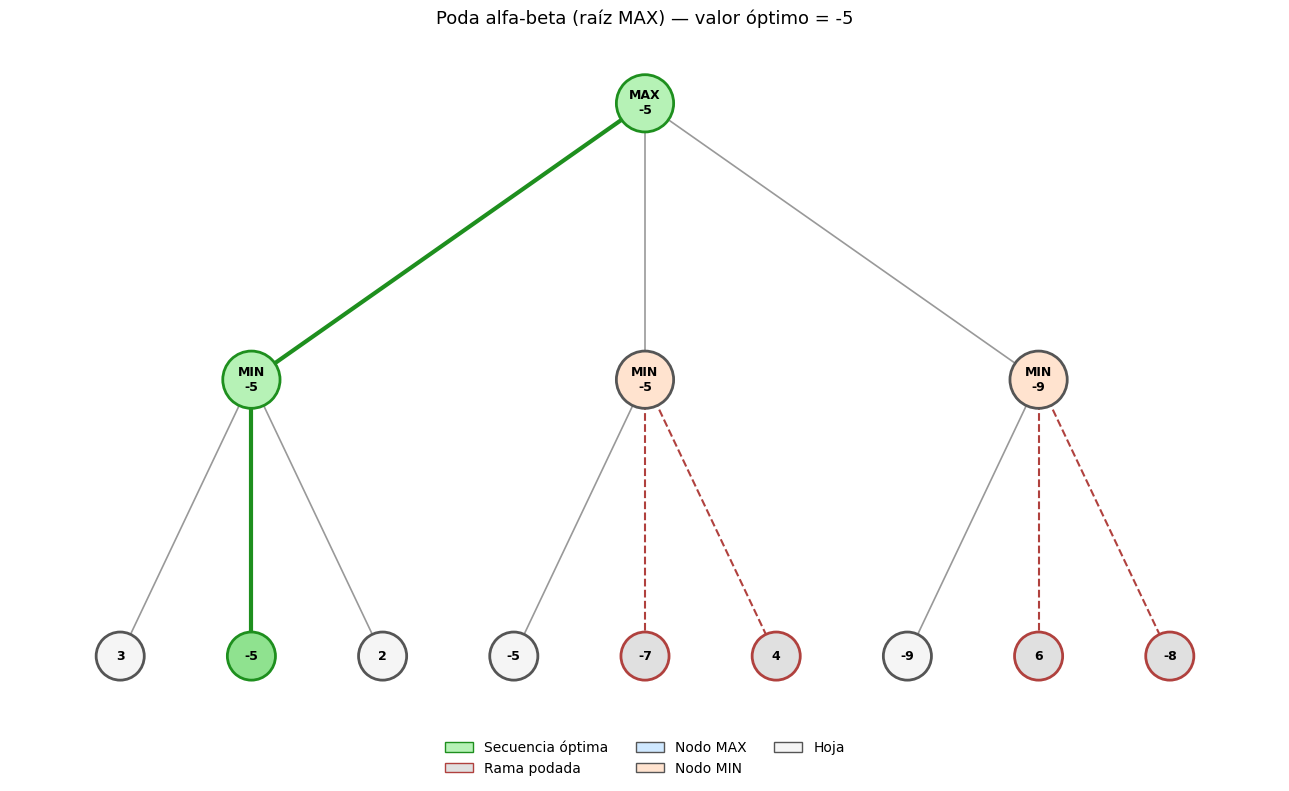

In [49]:
solver = AlphaBetaSolver(preferencia)

minimax_result = solver.minimax(tree)
alpha_beta_result = solver.alpha_beta_pruning(tree)

print("Preferencia raíz:", solver.preference.upper())
print()
print("Minimax (sin poda):")
print(minimax_result)
print()
print("Alpha-Beta (con poda):")
print("  valor:", alpha_beta_result["valor"])
print("  secuencia óptima:", alpha_beta_result["secuencia_optima"])
print("  ramas podadas:", len(alpha_beta_result["ramas_podadas"]))

print("\nArbol evaluado con poda alfa-beta:")
rendered_tree = solver.render_tree(tree, alpha_beta_result)
for line in rendered_tree:
    print(line)

print()
print("Resumen:")
print("Valor final:", alpha_beta_result["valor"])
print("Secuencia óptima:", alpha_beta_result["secuencia_optima"])
print("Podas:")
for prune in alpha_beta_result["ramas_podadas"]:
    print(prune)

print("\nGenerando figura del árbol...")
fig = solver.visualize(tree, alpha_beta_result)
plt.show()